In [1]:
import pandas as pd
# Library to manipulate matrices
import numpy as np
# Plotting library 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import ipywidgets as widgets
%matplotlib inline
import plotly.express as px

In [13]:
#Loading PJM Hourly data
data=pd.read_csv("PJME_hourly.csv")

In [3]:
#Analyzing data
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
#Analysing data
data.shape

(145366, 2)

In [5]:
#Analysing data
data.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


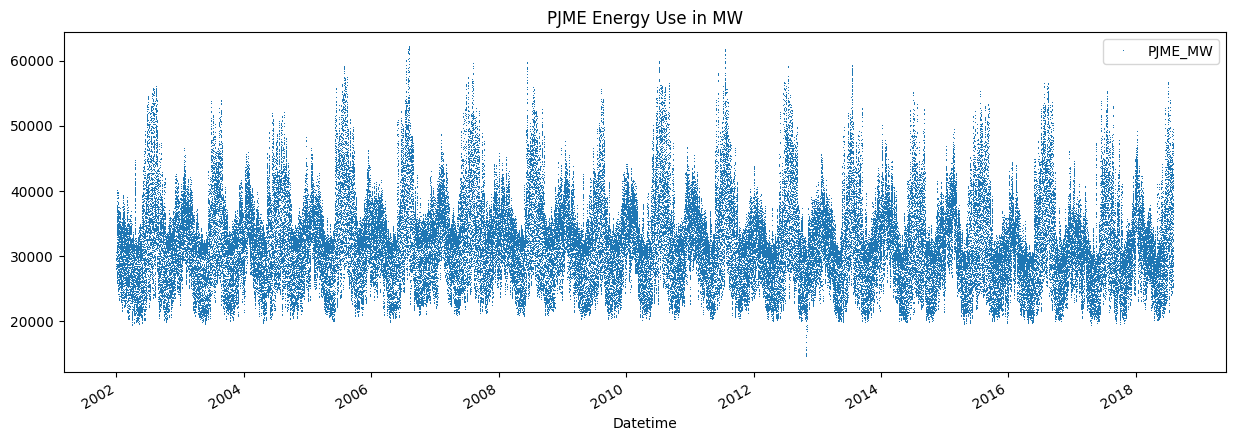

In [6]:
#Checking data types for columns
data.dtypes

#Datetime feature is object type, converting it to datetime
data["Datetime"]=pd.to_datetime(data["Datetime"])

#Setting Datetime as index to make panda operations easier
data_setindex=data.set_index("Datetime")

#Visulaizing Energy consumption as per datetime
data_setindex.plot(style=",", figsize=(15,5), title='PJME Energy Use in MW')
plt.show()
       

In [7]:
# Remove duplicate timestamps first
data_setindex = data_setindex[~data_setindex.index.duplicated(keep='first')]

# Check for missing timestamps
full_range = pd.date_range(start=data_setindex.index.min(), 
                           end=data_setindex.index.max(), freq='h')
missing = full_range.difference(data_setindex.index)
print(f"Missing timestamps: {len(missing)}")

# Reindex and impute
data_setindex = data_setindex.reindex(full_range)
data_setindex['PJME_MW'] = data_setindex['PJME_MW'].interpolate(method='time')
print(f"NaNs after imputation: {data_setindex.isna().sum().sum()}")

Missing timestamps: 30
NaNs after imputation: 0


30 missing hourly timestamps were detected in the dataset. These missing hours were not visible via `isna().sum()` as the rows were completely absent from the data.

Using `reindex()`, the missing hours were inserted as `NaN` rows to make the timeline continuous. These `NaN` values were then imputed using **time-weighted interpolation**, which estimates each missing value by considering its neighbouring previous and future data points — respecting the actual time gap between them

In [8]:
#  Dealing with outliers
# Compute Z-score 
z = np.abs((data_setindex['PJME_MW'] - data_setindex['PJME_MW'].mean()) / data_setindex['PJME_MW'].std())

# Filter outliers
outliers_z_score = data_setindex[z > 3]

# Print results
print(outliers_z_score)
print(len(outliers_z_score))

                     PJME_MW
2002-06-26 13:00:00  51677.0
2002-06-26 14:00:00  52637.0
2002-06-26 15:00:00  52938.0
2002-06-26 16:00:00  52894.0
2002-06-26 17:00:00  52148.0
...                      ...
2018-07-16 15:00:00  52742.0
2018-07-16 16:00:00  53408.0
2018-07-16 17:00:00  53764.0
2018-07-16 18:00:00  53352.0
2018-07-16 19:00:00  52226.0

[1320 rows x 1 columns]
1320


1,318 observations have Z-scores greater than 3, representing just 0.91% of the 145,366 total readings. These extreme values are concentrated in specific years — notably 2010 (168 hours) and 2005 (156 hours) — likely corresponding to heatwave events driving peak demand. Since they reflect genuine demand spikes rather than sensor errors, the outliers are retained as they carry useful signal for the model.

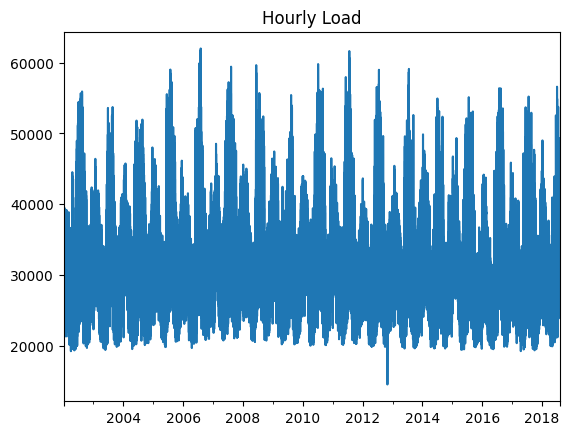

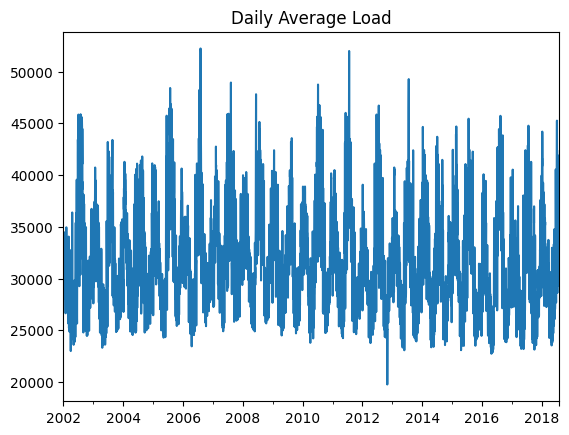

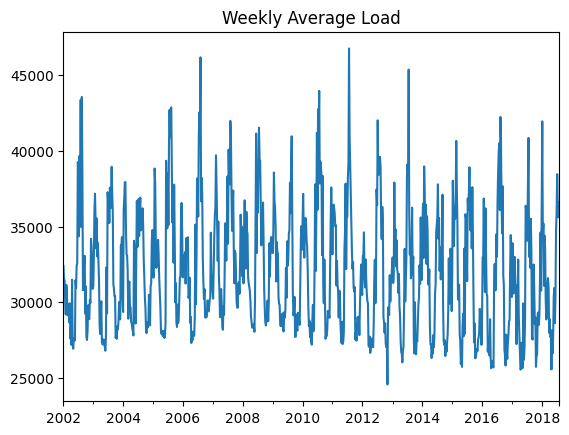

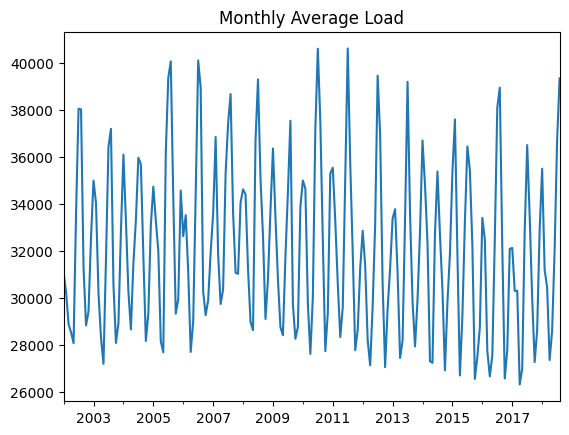

In [9]:
# Data is already at hourly frequency. Resampling is performed to analyze the data
# at different time scales (daily, weekly, monthly) using mean aggregation.

data_daily = data_setindex.resample("D").mean()
data_weekly = data_setindex.resample("W").mean()
data_monthly = data_setindex.resample("M").mean()

# Hourly
plt.figure()
data_setindex['PJME_MW'].plot(title="Hourly Load")

# Daily
plt.figure()
data_daily['PJME_MW'].plot(title="Daily Average Load")

# Weekly
plt.figure()
data_weekly['PJME_MW'].plot(title="Weekly Average Load")

# Monthly
plt.figure()
data_monthly['PJME_MW'].plot(title="Monthly Average Load")

plt.show()

The plots show that hourly data contains the most detailed information, including strong daily patterns and short term fluctuations, while daily, weekly, and monthly resampling progressively smooths the data and highlights broader trends but removes important temporal detail. Since electricity demand is highly influenced by hourly variations, especially daily cycles, using hourly data preserves the most relevant information for accurate forecasting. Therefore, hourly data is selected for modeling, while the resampled daily, weekly, and monthly data are used for exploratory analysis and understanding overall trends.

In [10]:
#Feature Engineering

import holidays

data_raw = data_setindex.copy()
data_featured = data_raw.copy()

# ── 1. Temporal ───────────────────────────────────────────────────────────────
data_featured['hour']        = data_featured.index.hour
data_featured['day_of_week'] = data_featured.index.dayofweek
data_featured['quarter']     = data_featured.index.quarter
data_featured['week']        = data_featured.index.isocalendar().week.values.astype(int)
data_featured['month']       = data_featured.index.month
data_featured['year']        = data_featured.index.year
data_featured['dayofyear']   = data_featured.index.dayofyear

# ── 2. Cyclical Encoding ──────────────────────────────────────────────────────
data_featured['hour_sin']  = np.sin(2 * np.pi * data_featured['hour'] / 24)
data_featured['hour_cos']  = np.cos(2 * np.pi * data_featured['hour'] / 24)
data_featured['month_sin'] = np.sin(2 * np.pi * data_featured['month'] / 12)
data_featured['month_cos'] = np.cos(2 * np.pi * data_featured['month'] / 12)
data_featured['dow_sin']   = np.sin(2 * np.pi * data_featured['day_of_week'] / 7)
data_featured['dow_cos']   = np.cos(2 * np.pi * data_featured['day_of_week'] / 7)

# ── 3. Holidays ───────────────────────────────────────────────────────────────
us_holidays = holidays.US()
data_featured['is_holiday']      = data_featured.index.normalize().map(
                                    lambda x: 1 if x in us_holidays else 0)
data_featured['days_to_holiday'] = data_featured.index.map(
                                    lambda x: min(abs((x.date() - h).days) 
                                    for h in us_holidays))

# ── 4. Statistical ────────────────────────────────────────────────────────────
data_featured['ma_7d']       = data_featured['PJME_MW'].rolling(window=7*24).mean()
data_featured['ma_30d']      = data_featured['PJME_MW'].rolling(window=30*24).mean()
data_featured['ma_90d']      = data_featured['PJME_MW'].rolling(window=90*24).mean()
data_featured['roll_std_7d'] = data_featured['PJME_MW'].rolling(window=7*24).std()
data_featured['roll_min_7d'] = data_featured['PJME_MW'].rolling(window=7*24).min()
data_featured['roll_max_7d'] = data_featured['PJME_MW'].rolling(window=7*24).max()
data_featured['ewma_7d']     = data_featured['PJME_MW'].ewm(span=7*24).mean()
data_featured['ewma_30d']    = data_featured['PJME_MW'].ewm(span=30*24).mean()
data_featured['diff_24h']    = data_featured['PJME_MW'].diff(24)
data_featured['diff_168h']   = data_featured['PJME_MW'].diff(168)

# ── 5. Lag Features ───────────────────────────────────────────────────────────
data_featured['lag_1h']   = data_featured['PJME_MW'].shift(1)
data_featured['lag_24h']  = data_featured['PJME_MW'].shift(24)
data_featured['lag_168h'] = data_featured['PJME_MW'].shift(168)

# ── 6. Domain Specific (external data not available) ─────────────────────────
# Temperature and daylight hours require external weather data — skipped

# ── Drop NaNs ─────────────────────────────────────────────────────────────────
data_featured.dropna(inplace=True)
print(f"Shape: {data_featured.shape}")
print(f"Features: {data_featured.columns.tolist()}")

print(f"Shape: {data_raw.shape}")
print(f"Features: {data_raw.columns.tolist()}")

Shape: (143233, 29)
Features: ['PJME_MW', 'hour', 'day_of_week', 'quarter', 'week', 'month', 'year', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_holiday', 'days_to_holiday', 'ma_7d', 'ma_30d', 'ma_90d', 'roll_std_7d', 'roll_min_7d', 'roll_max_7d', 'ewma_7d', 'ewma_30d', 'diff_24h', 'diff_168h', 'lag_1h', 'lag_24h', 'lag_168h']
Shape: (145392, 1)
Features: ['PJME_MW']


Fold 1 — Train: 99409, Val: 8760
Fold 2 — Train: 108169, Val: 8760
Fold 3 — Train: 116929, Val: 8760
Fold 4 — Train: 125689, Val: 8760
Fold 5 — Train: 134449, Val: 8760


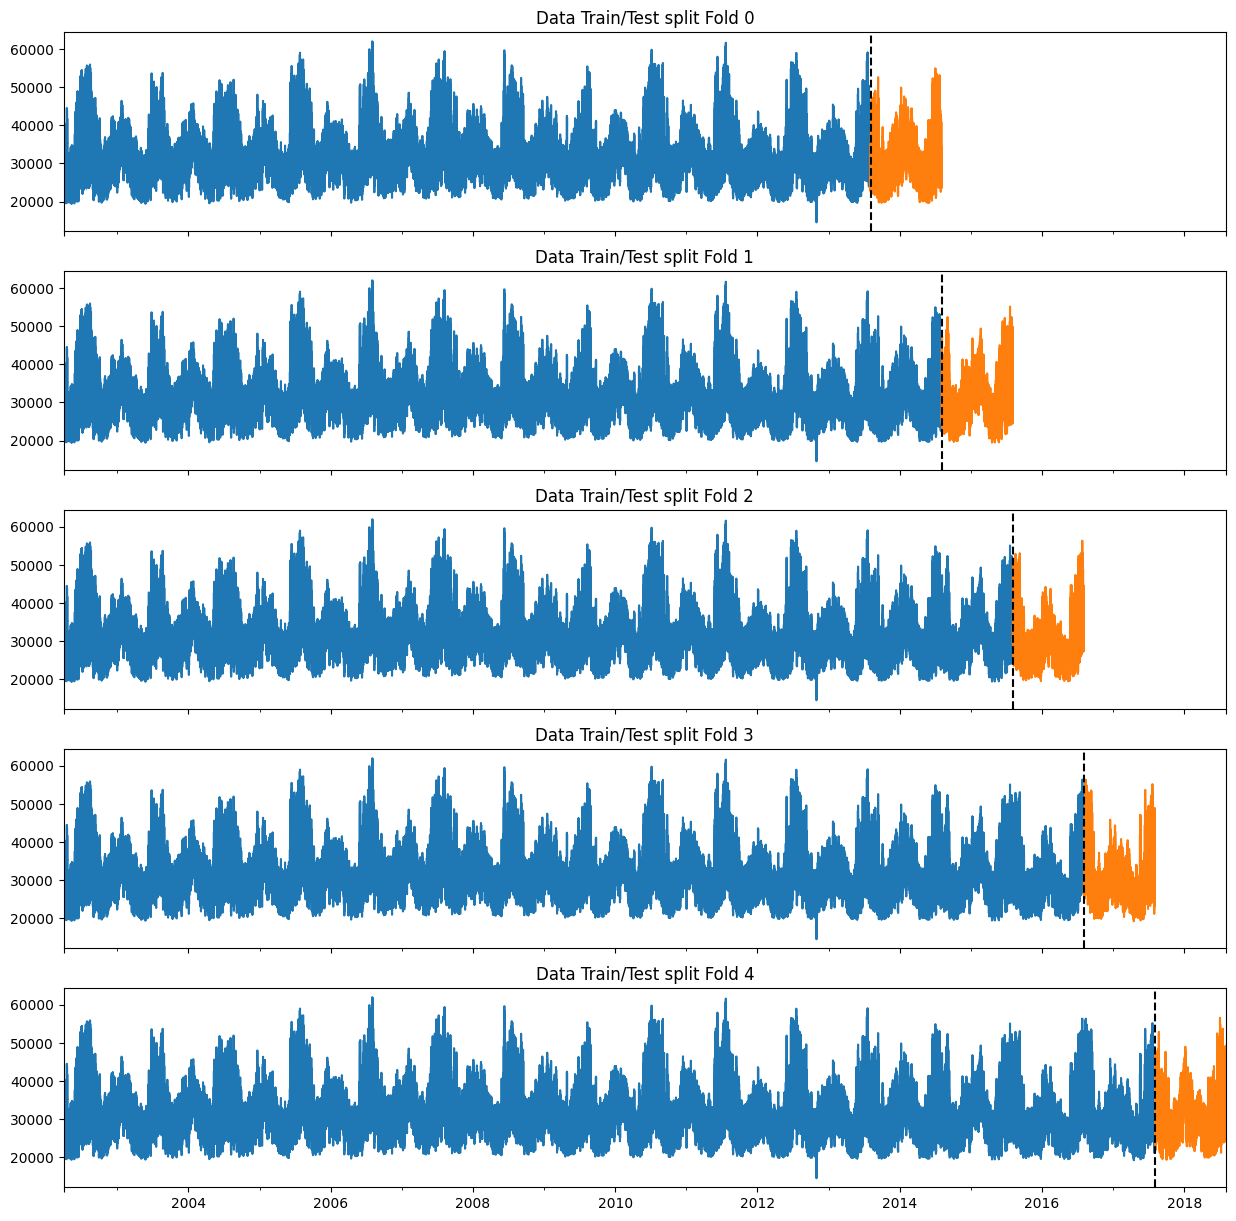

In [28]:
#Time Based Cross Validation
from sklearn.model_selection import TimeSeriesSplit

cv_data = data_featured

X = cv_data.drop(columns=['PJME_MW'])
y = cv_data['PJME_MW']

# Now run cross validation on cv_data only
tss = TimeSeriesSplit(
    n_splits=5,
    gap=24,          # 1 day
    test_size=8760   # 1 year
)

#Each fold keeps all previous training data and adds more — the window expands forward in time.
fig, axs = plt.subplots(5, 1,figsize = (15,15), sharex=True)

fold = 0

for fold, (train_index, val_index) in enumerate(tss.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    train =cv_data.iloc[train_index]
    test = cv_data.iloc[val_index]
    train['PJME_MW'].plot(ax = axs[fold],
                         label = 'Training Set',
                         title = f'Data Train/Test split Fold {fold}')
    test['PJME_MW'].plot(ax = axs[fold], label = 'Test Set')
    
    axs[fold].axvline(test.index.min(), color = 'black', ls = '--')
    print(f"Fold {fold+1} — Train: {len(X_train)}, Val: {len(X_val)}")

#Since linear based models will be used later, standardization is selected 

    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)